In [2]:
# coding: utf-8
# наше всё
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from pylab import rcParams

# настройки pandas, с которыми лучше почти всегда
pd.set_option('display.max_rows', 45000)
pd.set_option('display.max_columns', 50000)
pd.set_option('display.max_colwidth', 5000)

# графики в svg выглядят более четкими
%config InlineBackend.figure_format = 'svg' 
rcParams['figure.figsize'] = 16, 12

In [3]:
source_df = pd.read_excel('qval3.xlsx', sheet_name='Worksheet')

In [4]:
res_df = source_df.copy()
diff_df = res_df.copy()
for i in range(1, len(diff_df.columns)-2):
    diff_df[i] = np.sum(diff_df[i]) / len(diff_df[i])



pot_df = res_df.copy()
for i in range(1, len(diff_df.columns)-2):
    pot_df[i] = diff_df[i] * res_df[i]


diff_df = diff_df[0:1][diff_df.columns[3:]].T
diff_df = diff_df.reset_index()
diff_df.columns = ['question', 'difficulty']


In [5]:
diff_df.sample(3)

,question,difficulty
27,28,0.592593
30,31,0.629630
26,27,0.444444


In [6]:
diff_df.sort_values(by='difficulty', ascending=False)[0:3]

,question,difficulty
0,1,0.962963
17,18,0.962963
7,8,0.925926


In [7]:
diff_df.sort_values(by='difficulty', ascending=True)[0:3]

,question,difficulty
11,12,0.074074
21,22,0.111111
10,11,0.222222


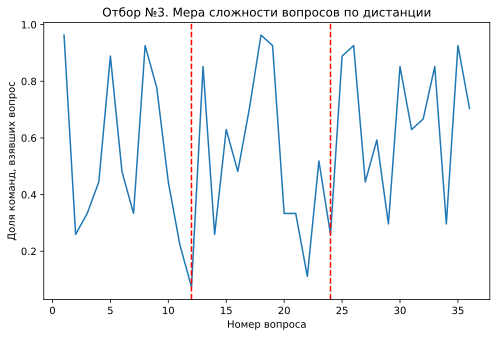

In [8]:
plt.figure(figsize=(8, 5))
sns.lineplot(data=diff_df, x='question', y='difficulty')
plt.xlabel('Номер вопроса')
plt.ylabel('Доля команд, взявших вопрос')
plt.title('Отбор №3. Мера сложности вопросов по дистанции')
#  вертикальная линия при x = 12 и x = 24
plt.axvline(x=12, color='red', linestyle='--')
plt.axvline(x=24, color='red', linestyle='--')
plt.show()


<Figure size 800x500 with 0 Axes>

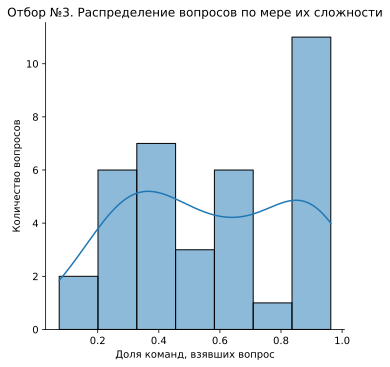

In [9]:
plt.figure(figsize=(8, 5))
sns.displot(diff_df['difficulty'], kde=True)
plt.xlabel('Доля команд, взявших вопрос')
plt.ylabel('Количество вопросов')
plt.title('Отбор №3. Распределение вопросов по мере их сложности')
plt.show()






In [10]:
team_stat = res_df[res_df.columns[0:3]].copy()
team_stat['result'] = np.sum(res_df[res_df.columns[3:]], axis=1)
team_stat['difficulty'] = np.sum(pot_df[pot_df.columns[3:]], axis=1)
team_stat['potential'] = team_stat['difficulty'] / team_stat['result']


In [11]:
team_stat.sort_values(by='result', ascending=False)

,Team ID,Название,Город,result,difficulty,potential
7,92069,"Возьми телефон, детка",Москва,30,18.592593,0.619753
1,80684,"И, конечно, лев",Москва,29,18.592593,0.641124
11,107808,Сучки ОКДФ,Москва,29,18.259259,0.629630
23,107811,Аффермации на апелляции,Москва,29,18.740741,0.646232
17,106699,"Один Кайфует, Двое Филонят",Москва,28,17.925926,0.640212
2,70231,"Чувствуешь, человек",Москва,28,18.222222,0.650794
21,86799,Будущего нет!,Москва,25,16.333333,0.653333
5,107756,Приказ скифского царя,Москва,24,16.925926,0.705247
12,107724,Не шиком лыты,Москва,24,16.259259,0.677469
13,44222,Рандом-2,Москва,23,16.666667,0.724638


In [12]:
team_stat[['result']].describe()

,result
count,27.000000
mean,20.592593
std,5.898235
min,11.000000
25%,16.000000
50%,21.000000
75%,24.500000
max,30.000000


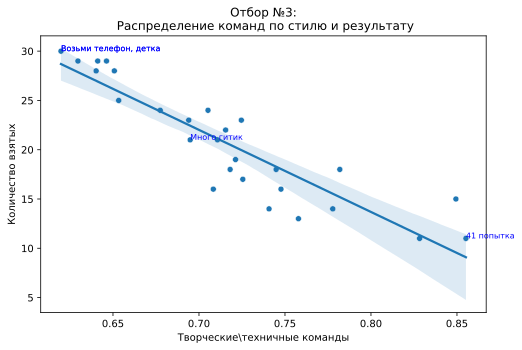

In [13]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=team_stat, 
    x="potential", 
    y="result",
    )

plt.title("Отбор №3:\n Распределение команд по стилю и результату")
# add a trend line
sns.regplot(data=team_stat, x="potential", y="result", scatter=False)

# add points
x1 = np.min(team_stat['potential'])
y1 = team_stat[team_stat['potential'] == x1]['result'].values[0]
name1 = team_stat[team_stat['potential'] == x1]['Название'].values[0]
plt.text(x1, y1, name1, fontsize=8, color='blue')

x2 = np.max(team_stat['potential'])
y2 = team_stat[team_stat['potential'] == x2]['result'].values[0]
name2 = team_stat[team_stat['potential'] == x2]['Название'].values[0]
plt.text(x2, y2, name2, fontsize=8, color='blue')

y3 = np.max(team_stat['result'])
x3 = team_stat[team_stat['result'] == y3]['potential'].values[0]
name3 = team_stat[team_stat['result'] == y3]['Название'].values[0]
plt.text(x3, y3, name3, fontsize=8, color='blue')

# y4 = np.min(team_stat['result'])
# x4 = team_stat[team_stat['result'] == y4]['potential'].values[0]
# name4 = team_stat[team_stat['result'] == y4]['Название'].values[0]
# plt.text(x4, y4, name4, fontsize=8, color='blue')

x5 = team_stat['potential'].values[np.random.randint(0, len(team_stat))]
y5 = team_stat[team_stat['potential'] == x5]['result'].values[0]
name5 = team_stat[team_stat['potential'] == x5]['Название'].values[0]
plt.text(x5, y5, name5, fontsize=8, color='blue')

plt.xlabel("Творческие\техничные команды")
plt.ylabel("Количество взятых")

plt.show()


In [14]:
# сильные техничные команды
team_stat[
    (team_stat['potential'] > np.mean(team_stat['potential'])) & 
    (team_stat['result'] > np.mean(team_stat['result']))
]['Название']

13    Рандом-2
Name: Название, dtype: object

In [15]:
# сильные творческие команды
team_stat[
    (team_stat['potential'] < np.mean(team_stat['potential'])) & 
    (team_stat['result'] > np.mean(team_stat['result']))
]['Название']

1                 И, конечно, лев
2             Чувствуешь, человек
3                     Много гитик
5           Приказ скифского царя
6                          ТиГриб
7           Возьми телефон, детка
9     Ультрафиолетовая катастрофа
11                     Сучки ОКДФ
12                  Не шиком лыты
17     Один Кайфует, Двое Филонят
21                  Будущего нет!
22               Баклажанна Д Арк
23        Аффермации на апелляции
Name: Название, dtype: object

In [16]:
team_stat.sort_values(by='potential', ascending=True)[0:5]

,Team ID,Название,Город,result,difficulty,potential
7,92069,"Возьми телефон, детка",Москва,30,18.592593,0.619753
11,107808,Сучки ОКДФ,Москва,29,18.259259,0.629630
17,106699,"Один Кайфует, Двое Филонят",Москва,28,17.925926,0.640212
1,80684,"И, конечно, лев",Москва,29,18.592593,0.641124
23,107811,Аффермации на апелляции,Москва,29,18.740741,0.646232


In [17]:
team_qv_df = res_df.melt(
    id_vars=['Название', 'Город', 'Team ID'],
    value_vars=res_df.columns[3:],
    var_name='question',
    value_name='qv_result'
)
team_qv_df = team_qv_df.merge(
    diff_df, 
    'left',
    on='question'
)
team_qv_df = team_qv_df.merge(
    team_stat,
    'left',
    on=['Название', 'Team ID', 'Город'],
    suffixes=('_qv', '_total')
)
team_qv_df['epic'] = team_qv_df['result'] * team_qv_df['difficulty_qv']




In [18]:
# топ эпических взятий
team_qv_df[team_qv_df['qv_result'] == 1].sort_values(by='epic', ascending=True)[0:3]

,Название,Город,Team ID,question,qv_result,difficulty_qv,result,difficulty_total,potential,epic
318,Будущего нет!,Москва,86799,12,1,0.074074,25,16.333333,0.653333,1.851852
581,Кафка на завтрак,Москва,86814,22,1,0.111111,17,12.333333,0.725490,1.888889
299,"Чувствуешь, человек",Москва,70231,12,1,0.074074,28,18.222222,0.650794,2.074074


In [19]:
# топ эпических продолбов
team_qv_df[team_qv_df['qv_result'] == 0].sort_values(by='epic', ascending=False)[0:4]

,Название,Город,Team ID,question,qv_result,difficulty_qv,result,difficulty_total,potential,epic
925,"Возьми телефон, детка",Москва,92069,35,0,0.925926,30,18.592593,0.619753,27.777778
654,ТиГриб,Москва,80660,25,0,0.888889,23,15.962963,0.694042,20.444444
237,Будущего нет!,Москва,86799,9,0,0.777778,25,16.333333,0.653333,19.444444
10,Горгонзола с маракуйей,Москва,107807,1,0,0.962963,19,13.703704,0.721248,18.296296


In [20]:
res_df = res_df.merge(
    team_stat,
    'left',
    on=['Название', 'Team ID', 'Город'],
    suffixes=('_qv', '_total')
)
res_df.sample(3)


,Team ID,Название,Город,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,result,difficulty,potential
10,107807,Горгонзола с маракуйей,Москва,0,0,0,0,1,0,0,1,1,0,0,0,1,0,1,0,1,1,1,0,0,0,1,0,1,1,1,1,1,0,1,1,1,1,1,0,19,13.703704,0.721248
22,96014,Баклажанна Д Арк,Москва,1,0,1,0,1,1,0,1,0,1,1,0,1,0,1,0,1,1,1,0,0,0,1,0,1,1,0,0,1,1,1,0,1,0,1,1,21,14.925926,0.710758
24,107544,Тамбовский Волк,Москва,1,1,1,0,1,0,0,1,0,1,0,0,1,1,1,0,0,1,1,1,0,0,0,0,0,1,0,0,0,1,0,0,1,0,1,0,16,11.333333,0.708333


In [21]:
# корреляция между столбцам в data frame
correlations_with_result = pd.DataFrame(res_df[res_df.columns[3:-2]].corr()['result'])
correlations_with_result.columns = ['correlation']
correlations_with_result.sort_values(by='correlation', ascending=False)[0:7]

,correlation
result,1.000000
31,0.807330
34,0.676289
13,0.601091
17,0.584940
11,0.560944
21,0.538445


In [22]:
correlations_with_result.sort_values(by='correlation', ascending=True)[0:5]

,correlation
35,-0.117643
1,0.053962
18,0.087846
25,0.199089
30,0.204811


In [23]:
res_df.sample(3)

,Team ID,Название,Город,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,result,difficulty,potential
15,92017,7 кликов мышкой,Москва,1,0,0,0,1,1,0,1,1,0,0,0,1,0,0,1,1,1,1,0,0,0,0,0,1,0,0,1,0,1,1,1,1,0,1,1,18,14.074074,0.781893
13,44222,Рандом-2,Москва,1,0,1,0,1,0,0,1,1,0,0,0,1,0,1,1,1,1,1,1,1,0,1,0,1,1,0,1,0,1,1,1,1,0,1,1,23,16.666667,0.724638
17,106699,"Один Кайфует, Двое Филонят",Москва,1,1,0,1,1,1,1,1,1,1,0,0,1,1,0,1,1,1,1,0,1,1,0,0,1,1,1,1,1,1,1,1,1,0,1,1,28,17.925926,0.640212


In [24]:
top_3 = list(correlations_with_result.sort_values(by='correlation', ascending=False)[1:4].index)
top_5 = list(correlations_with_result.sort_values(by='correlation', ascending=False)[1:6].index)

In [25]:
res_df['top-3'] = np.sum(res_df[res_df.columns[res_df.columns.isin(top_3)]], axis=1)
res_df['top-5'] = np.sum(res_df[res_df.columns[res_df.columns.isin(top_5)]], axis=1)
res_df.sample(3)






,Team ID,Название,Город,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,result,difficulty,potential,top-3,top-5
17,106699,"Один Кайфует, Двое Филонят",Москва,1,1,0,1,1,1,1,1,1,1,0,0,1,1,0,1,1,1,1,0,1,1,0,0,1,1,1,1,1,1,1,1,1,0,1,1,28,17.925926,0.640212,2,3
12,107724,Не шиком лыты,Москва,1,1,0,1,1,0,0,1,1,1,0,0,1,0,1,0,1,1,1,0,0,0,1,1,1,1,1,1,1,1,1,0,1,1,1,0,24,16.259259,0.677469,3,4
18,107809,41 попытка,Москва,1,0,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,1,1,0,0,0,1,0,0,1,0,1,0,11,9.407407,0.855219,0,0


In [26]:
res_df[['top-3', 'top-5', 'result']].corr()

,top-3,top-5,result
top-3,1.000000,0.936212,0.885293
top-5,0.936212,1.000000,0.892494
result,0.885293,0.892494,1.000000
